# Driving PyBERT's MCP Server from a Notebook

This notebook is the interactive counterpart to `examples/mcp_client.py`: it drives PyBERT's
MCP server as a real MCP client would, spawning `pybert mcp` as a subprocess and talking to it
over stdio.

It exercises all four capability groups the server exposes:

1. **Configuration** &mdash; `get_default_config`
2. **Simulation** &mdash; `run_simulation`
3. **Results browsing** &mdash; `inspect_results_file`
4. **IBIS-AMI introspection** &mdash; `list_ibis_models`, `inspect_ibis_model`

**Prerequisite:** the `mcp` extra must be installed: `uv sync --extra mcp` (or `pip install
"pipbert[mcp]"`).

**Note:** this notebook must be run with a kernel started from the repo root (or adjust
`REPO_ROOT` below), since PyBERT resolves config/model file paths relative to the MCP server
process's working directory.

**Why one big call cell?** The MCP stdio transport (`anyio`) opens a task group that must be
entered and exited from the *same* asyncio task. Jupyter runs each cell's top-level `await` as a
new task, so a session opened in one cell can't be used or closed from a later one. The cell below
therefore makes the whole round of tool calls in a single `async with` block and stashes the
results in plain Python variables; every cell after that just inspects those variables (no `await`
needed, so no task-boundary problem).

In [1]:
import json
from pathlib import Path

from mcp import ClientSession, StdioServerParameters, stdio_client

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent  # running from examples/

EXAMPLE_IBIS_FILE = "models/ibisami/example_rx.ibs"  # relative to REPO_ROOT
RESULTS_FILE = str(REPO_ROOT / "examples" / "mcp_notebook_results.pybert_data")


def _json(result) -> dict:
    """Pull the JSON payload out of a `CallToolResult`."""
    return json.loads(result.content[0].text)

## Talk to the server

One session, all six tool calls, in order. Re-run this cell any time you want a fresh round trip
against the server (e.g. after editing a config override below).

In [2]:
params = StdioServerParameters(command="uv", args=["run", "pybert", "mcp"], cwd=str(REPO_ROOT))

async with stdio_client(params) as (read, write), ClientSession(read, write) as session:
    await session.initialize()

    tools = await session.list_tools()
    print("Available tools:", ", ".join(sorted(t.name for t in tools.tools)))

    # 1. Configuration: fetch PyBERT's default configuration.
    config = _json(await session.call_tool("get_default_config", {}))
    print(f"\nDefault config has {len(config)} settings, e.g. bit_rate={config['bit_rate']} Gbps")

    # 2. Simulation: shrink the bit count for speed, then run.
    config["nbits"] = 1000
    config["eye_bits"] = 500
    metrics = _json(await session.call_tool("run_simulation", {"config": config}))
    print(f"\nSimulation status: {metrics['status']}")
    print(f"Total jitter/noise-limited performance: {metrics['total_perf']:.3g} bits/s")

    # 3. Results browsing: re-run with `results_file` set, so waveforms get saved, then inspect them.
    await session.call_tool("run_simulation", {"config": config, "results_file": RESULTS_FILE})
    summary = _json(await session.call_tool("inspect_results_file", {"results_file": RESULTS_FILE}))
    print(f"\n{len(summary)} waveform arrays saved, e.g. chnl_h: {summary['chnl_h']}")

    # 4. IBIS-AMI introspection.
    ibis_info = _json(await session.call_tool("list_ibis_models", {"ibis_file": EXAMPLE_IBIS_FILE}))
    print(f"\n{EXAMPLE_IBIS_FILE}: components={ibis_info['components']}, models={ibis_info['models']}")

    model_name = ibis_info["models"][0]
    model_info = _json(
        await session.call_tool("inspect_ibis_model", {"ibis_file": EXAMPLE_IBIS_FILE, "model_name": model_name})
    )
    print(f"\n{model_name}: is_ami={model_info['is_ami']}, type={model_info['type']}")

Available tools: get_config, get_default_config, inspect_ibis_model, inspect_results_file, list_ibis_models, run_simulation, set_config

Default config has 88 settings, e.g. bit_rate=10.0 Gbps

Simulation status: Ready.
Total jitter/noise-limited performance: 3.03e+05 bits/s

23 waveform arrays saved, e.g. chnl_h: {'shape': [640], 'dtype': 'float64', 'min': 1.867756818921923e-05, 'max': 0.012641013309207678, 'mean': 0.0007597733008077639}

models/ibisami/example_rx.ibs: components=['Example_Rx'], models=['example_rx']

example_rx: is_ami=True, type=Input


## Inspect the results

Everything from here on is plain Python &mdash; no more `await`, just looking at the dicts the
cell above stashed.

In [3]:
print(json.dumps(metrics, indent=2))

{
  "status": "Ready.",
  "total_perf": 303119.16923251457,
  "jitter_perf": 2050340.210735076,
  "n_errs_dfe": 0,
  "n_errs_viterbi": -1,
  "chnl_dly": 2.3812500000000002e-09,
  "isi_dfe": 2.529571747261402e-11,
  "dcd_dfe": 2.5686152568952654e-12,
  "pj_dfe": 1.6475914203408647e-12,
  "rj_dfe": 1.1103009864100038e-11,
  "perf_info": "<H2>Performance by Component</H2>\n  <TABLE border=\"1\">\n    <TR align=\"center\">\n      <TH>Component</TH><TH>Performance (Msmpls./min.)</TH>\n    </TR>\n    <TR align=\"right\">\n      <TD align=\"center\">Channel</TD><TD>63.825</TD>\n    </TR>\n    <TR align=\"right\">\n      <TD align=\"center\">Tx Preemphasis</TD><TD>345.541</TD>\n    </TR>\n    <TR align=\"right\">\n      <TD align=\"center\">CTLE</TD><TD>157.980</TD>\n    </TR>\n    <TR align=\"right\">\n      <TD align=\"center\">FFE</TD><TD>465.911</TD>\n    </TR>\n    <TR align=\"right\">\n      <TD align=\"center\">DFE</TD><TD>50.580</TD>\n    </TR>\n    <TR align=\"right\">\n      <TD alig

In [4]:
print(json.dumps(summary, indent=2))

{
  "chnl_h": {
    "shape": [
      640
    ],
    "dtype": "float64",
    "min": 1.867756818921923e-05,
    "max": 0.012641013309207678,
    "mean": 0.0007597733008077639
  },
  "tx_out_h": {
    "shape": [
      640
    ],
    "dtype": "float64",
    "min": 0.0,
    "max": 0.012641013309207678,
    "mean": 0.0007566076416065674
  },
  "ctle_out_h": {
    "shape": [
      640
    ],
    "dtype": "float64",
    "min": -1.5553752483938216e-05,
    "max": 0.012374019171556502,
    "mean": 0.0007100476099718481
  },
  "dfe_out_h": {
    "shape": [
      640
    ],
    "dtype": "float64",
    "min": -1.5553752483938216e-05,
    "max": 0.012374019171556502,
    "mean": 0.0006970391785260132
  },
  "chnl_s": {
    "shape": [
      640
    ],
    "dtype": "float64",
    "min": 0.00017333743386144625,
    "max": 0.4862549125169685,
    "mean": 0.4468304970141168
  },
  "tx_s": {
    "shape": [
      640
    ],
    "dtype": "float64",
    "min": 0.0,
    "max": 1.0,
    "mean": 0.85
  },
  "ct

In [5]:
print(json.dumps(model_info, indent=2))

{
  "type": "Input",
  "is_ami": true,
  "zout": null,
  "zin": 50.000000000000014,
  "ccomp": [
    1e-12,
    1e-14,
    5e-12
  ],
  "slew": null,
  "ami_files": {
    "32-bit": {
      "lin": [
        "example_rx_x86.so",
        "example_rx.ami"
      ],
      "win": [
        "example_rx_x86.dll",
        "example_rx.ami"
      ]
    },
    "64-bit": {
      "lin": [
        "example_rx_x86_amd64.so",
        "example_rx.ami"
      ],
      "win": [
        "example_rx_x86_amd64.dll",
        "example_rx.ami"
      ]
    }
  },
  "test_configs": [],
  "summary": "Model Type:\tInput\nC_comp:    \t[1e-12, 1e-14, 5e-12]\nCref:      \tNone\nVref:      \tNone\nVmeas:     \tNone\nRref:      \tNone\nTemperature Range:\t[25.0, 0.0, 100.0]\nVoltage Range:    \t[1.8, 1.62, 1.98]\nAlgorithmic Model:\n\t32-bit:\n\t\tLinux: ['example_rx_x86.so', 'example_rx.ami']\n\t\tWindows: ['example_rx_x86.dll', 'example_rx.ami']\n\t64-bit:\n\t\tLinux: ['example_rx_x86_amd64.so', 'example_rx.ami']\n\t\tW

### Bonus: plotting the channel impulse response

`inspect_results_file` only reports summary statistics over MCP &mdash; that's a deliberate
design choice, so a tool result stays small even for arrays with hundreds of thousands of
samples. To actually plot a waveform, unpickle the saved file directly (this part talks to the
filesystem, not the MCP server).

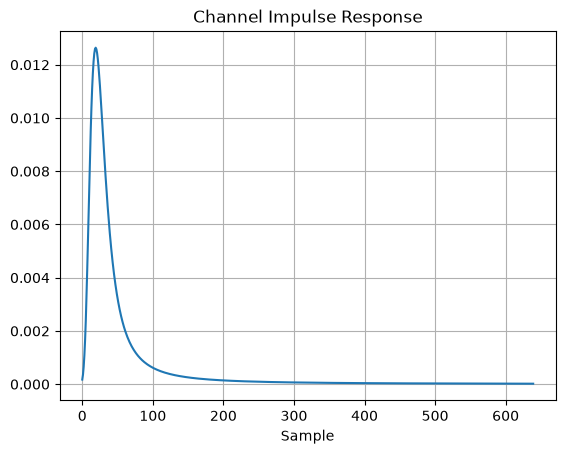

In [6]:
import pickle

import matplotlib.pyplot as plt

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

chnl_h = saved.the_data.arrays["chnl_h"]
plt.plot(chnl_h)
plt.title("Channel Impulse Response")
plt.xlabel("Sample")
plt.grid()
plt.show()

Path(RESULTS_FILE).unlink(missing_ok=True)